# *Predicting House Prices with Linear Regression*

## *Objective*
The objective of this project is to build a predictive model to estimate house prices based on various features such as area, number of rooms, and amenities using Linear Regression.

In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
import pandas as pd

housing = pd.read_csv("Housing.csv")
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## *Dataset Overview*

In [24]:
housing.shape
housing.info()
housing.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


The dataset contains 545 observations and 13 features describing various attributes of houses such as area, number of bedrooms, bathrooms, stories, parking, and amenities. The target variable is price, which is continuous in nature.

## *Data Cleaning*

In [25]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [26]:
housing.replace({'yes':1, 'no':0}, inplace=True)

In [27]:
housing['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [28]:
housing= pd.get_dummies(housing, drop_first=True)

The dataset was examined for missing values and no null values were found. Categorical variables such as 'yes' and 'no' were converted into numerical values (1 and 0). The 'furnishingstatus' variable was encoded using one-hot encoding to make it suitable for model training.

In [29]:
housing.info()
housing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [30]:
housing=housing.astype(int)
housing.head()
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

## *Exploratory Data Analysis*

### *Correlation Heatmap*

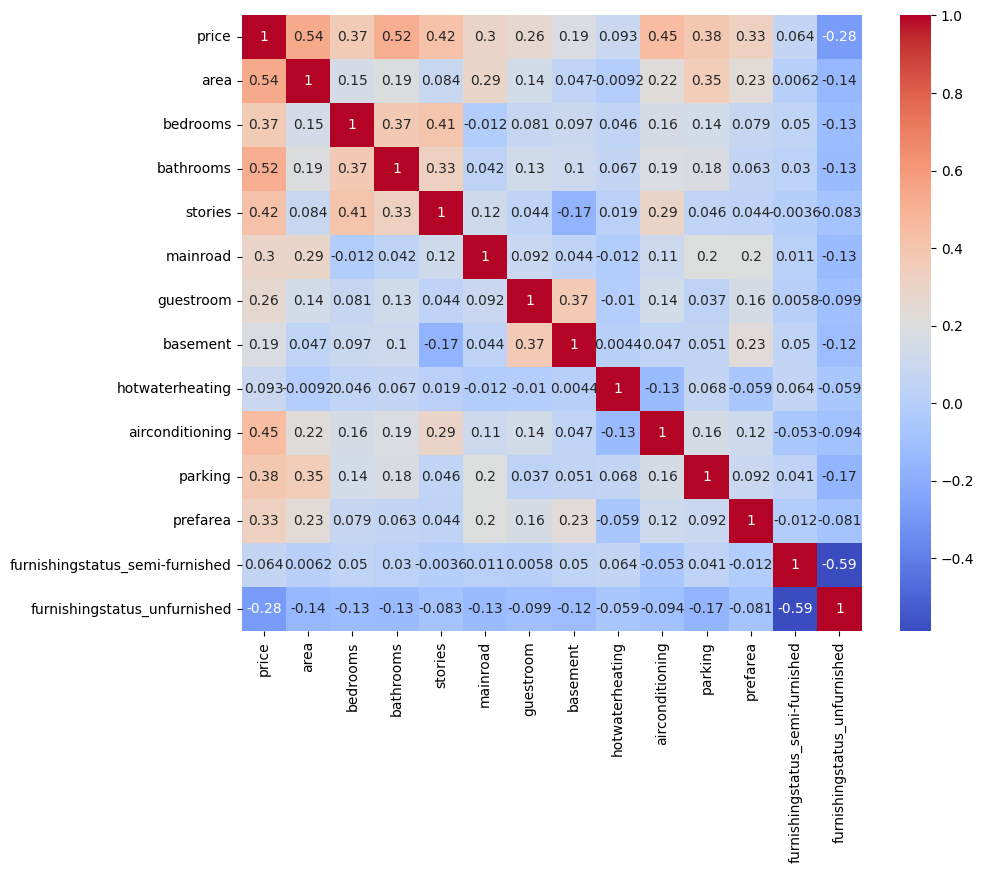

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,8))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm')
plt.show()

Correlation analysis revealed that area, number of bathrooms, and air conditioning have strong positive relationships with house prices. Features such as stories and parking also show moderate positive correlation. Additionally, unfurnished houses show a negative correlation with price, indicating that they tend to have lower value compared to furnished houses.

### *Feature Selection*

In [32]:
X= housing.drop('price', axis=1)
y= housing['price']

All available features were used as independent variables (X), while price was selected as the dependent variable (y). No feature was removed at this stage to retain maximum information for model training.

### *Train-Test Split*

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### *Model Building*

We now train a Linear Regression model to learn the relationship between features and house price.

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


A Linear Regression model was used to establish a relationship between house features and price. The dataset was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

### *Model Coefficients (Interpretation)*

In [35]:
import pandas as pd

coeff_df= pd.DataFrame(model.coef_, X_train.columns, columns=['Coefficient'])
print(coeff_df)

                                  Coefficient
area                             2.359688e+02
bedrooms                         7.677870e+04
bathrooms                        1.094445e+06
stories                          4.074766e+05
mainroad                         3.679199e+05
guestroom                        2.316100e+05
basement                         3.902512e+05
hotwaterheating                  6.846499e+05
airconditioning                  7.914267e+05
parking                          2.248419e+05
prefarea                         6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
furnishingstatus_unfurnished    -4.136451e+05


The coefficients of the model indicate that:

Bathrooms, air conditioning, and preferred area have strong positive effects on house price.
Area also positively contributes to price increase.
Furnishing status negatively impacts price when the house is semi-furnished or unfurnished compared to furnished houses.

### *Predictions*

In [36]:
y_pred = model.predict(X_test)

## *Model Evaluation*

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
r2= r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 1754318687330.6628
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


The model achieved an R² score of approximately 0.65, indicating that it explains around 65% of the variance in house prices.
The RMSE value (~1.32 million) suggests that predictions deviate from actual values by a moderate margin.

## *Visualization*

### *Actual vs Predicted*

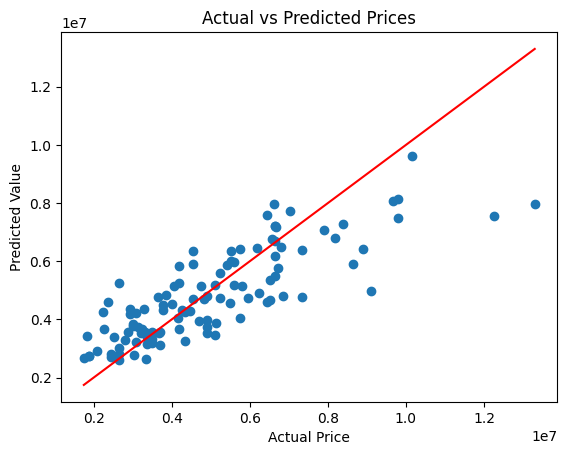

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted Prices")
plt.show()

The scatter plot shows a positive relationship between actual and predicted values, indicating that the model captures general trends. However, the spread of points suggests prediction errors.

### *Residual Plot*

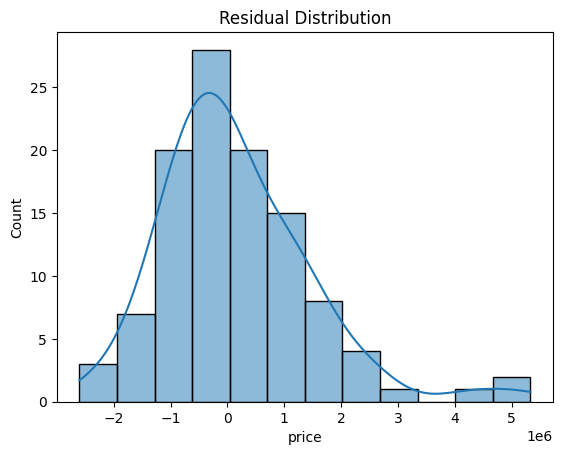

In [39]:
residuals = y_test- y_pred

import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

The residual distribution appears approximately normal, indicating that the model errors are reasonably distributed and the model assumptions are partially satisfied.

### *Sample Predictions*

In [40]:
sample = X_test.iloc[0].values.reshape(1,-1)
predicted_price = model.predict(sample)

print("Predicted Price:", predicted_price[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 5164653.900339675
Actual Price: 4060000


In [41]:
for i in range(5):
    sample = X_test.iloc[i].values.reshape(1, -1)
    pred = model.predict(sample)
    
    print(f"Sample {i+1}")
    print("Predicted:", pred[0])
    print("Actual:", y_test.iloc[i])
    print("------")

Sample 1
Predicted: 5164653.900339675
Actual: 4060000
------
Sample 2
Predicted: 7224722.298021666
Actual: 6650000
------
Sample 3
Predicted: 3109863.2424033806
Actual: 3710000
------
Sample 4
Predicted: 4612075.327225597
Actual: 6440000
------
Sample 5
Predicted: 3294646.257259555
Actual: 2800000
------


## *Key Insights*

- Area, bathrooms, and air conditioning strongly influence house prices  
- Furnishing status negatively impacts price  
- Preferred area increases property value  

## *Limitations*

- Linear Regression assumes linear relationships  
- Moderate accuracy (R² ≈ 0.65)  
- Possible missing features  

## *Final Conclusion*

This project demonstrates the application of Linear Regression in predicting house prices. The model achieves moderate performance and successfully identifies key factors affecting prices. Further improvements can enhance prediction accuracy. The model captures general trends but may not fully represent complex nonlinear relationships in housing prices.